# PPThinning\n\nSimulating point processes by thinning.\n\nPython port of the MATLAB `PPThinning` helpfile (`helpfiles/PPThinning.m`).

## Simulate PP via thinning

Given a conditional intensity function, we generate a point process consistent with this CIF.

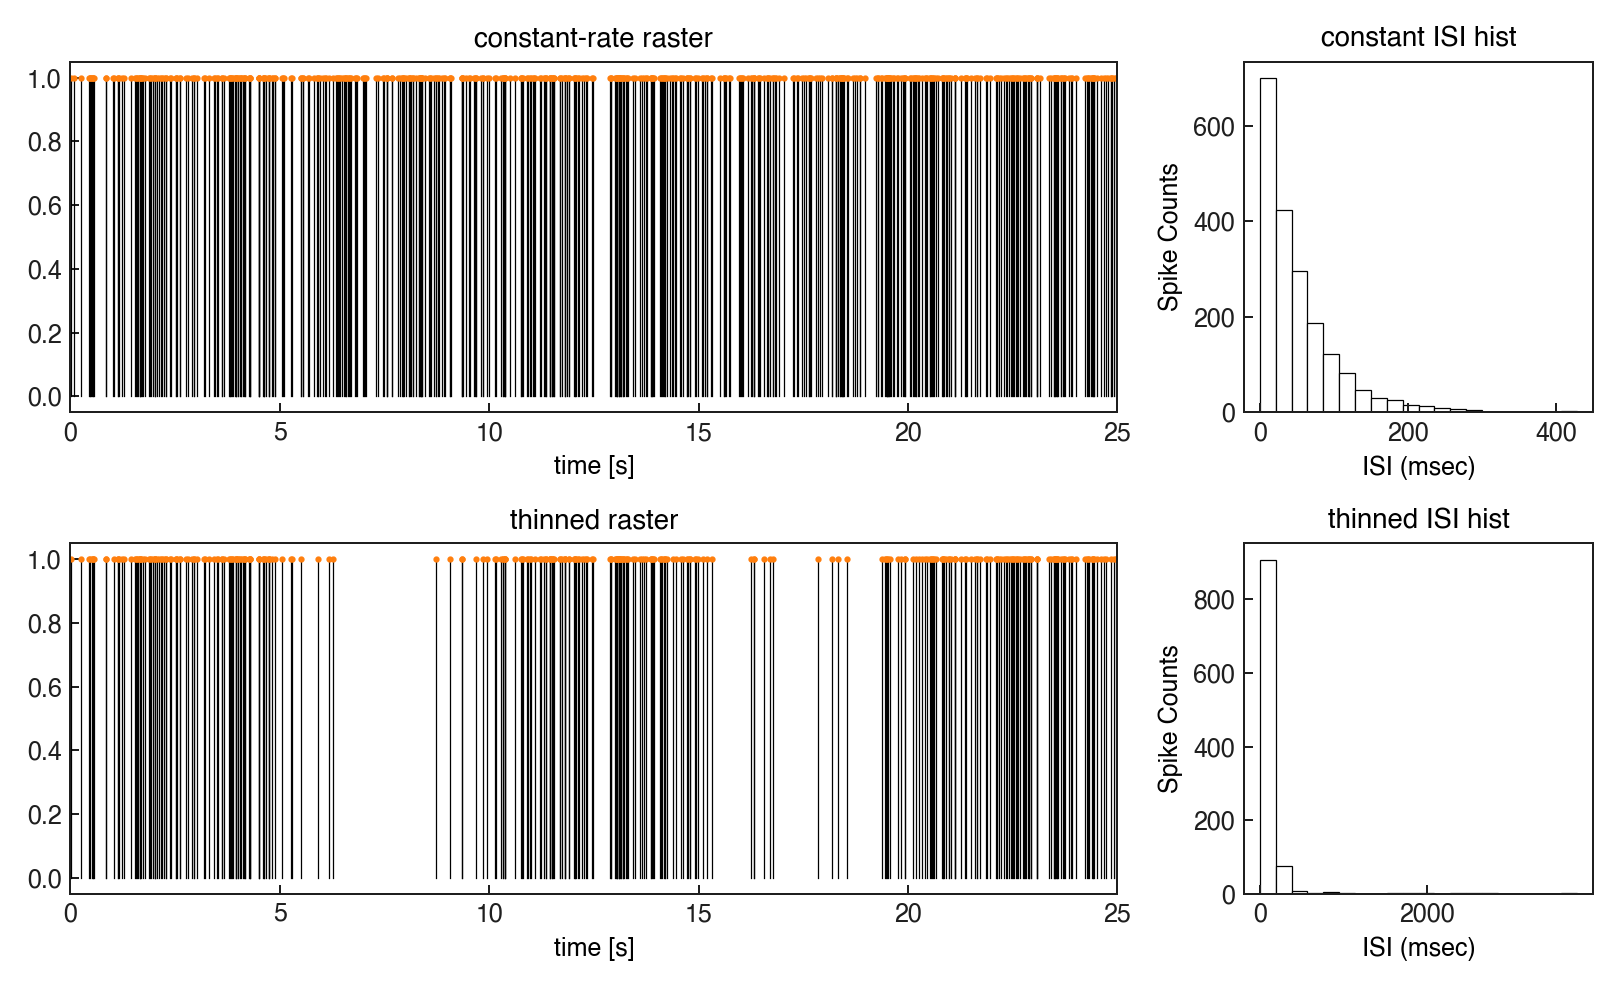

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import Covariate, nspikeTrain, nstColl, CIF
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="PPThinning", output_root=OUTPUT_ROOT, expected_count=4)
def capture(label, fn):
    fig = __tracker.new_figure(label); plt.close(fig); fn(); __tracker._active_fig = plt.gcf()


## Basic Example

In [ ]:
# SECTION 1: Basic Example
delta = 0.001; Tmax = 100; time = np.arange(0, Tmax + delta, delta); f = 0.1
lambdaData = 10*np.sin(2*np.pi*f*time) + 10
lam = Covariate(time, lambdaData, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
lambdaBound = float(np.max(lambdaData))
rng = np.random.default_rng(0)
N = int(lambdaBound * 1.5 * Tmax)
u = rng.random(N); w = -np.log(u) / lambdaBound
tSpikes = np.cumsum(w); tSpikes = tSpikes[tSpikes <= Tmax]
ratio = np.asarray(lam.getValueAt(tSpikes)).flatten() / lambdaBound
u2 = rng.random(len(ratio)); tThin = tSpikes[ratio >= u2]
n1 = nspikeTrain(tSpikes); n2 = nspikeTrain(tThin)

## Compare Constant rate process vs. thinned process

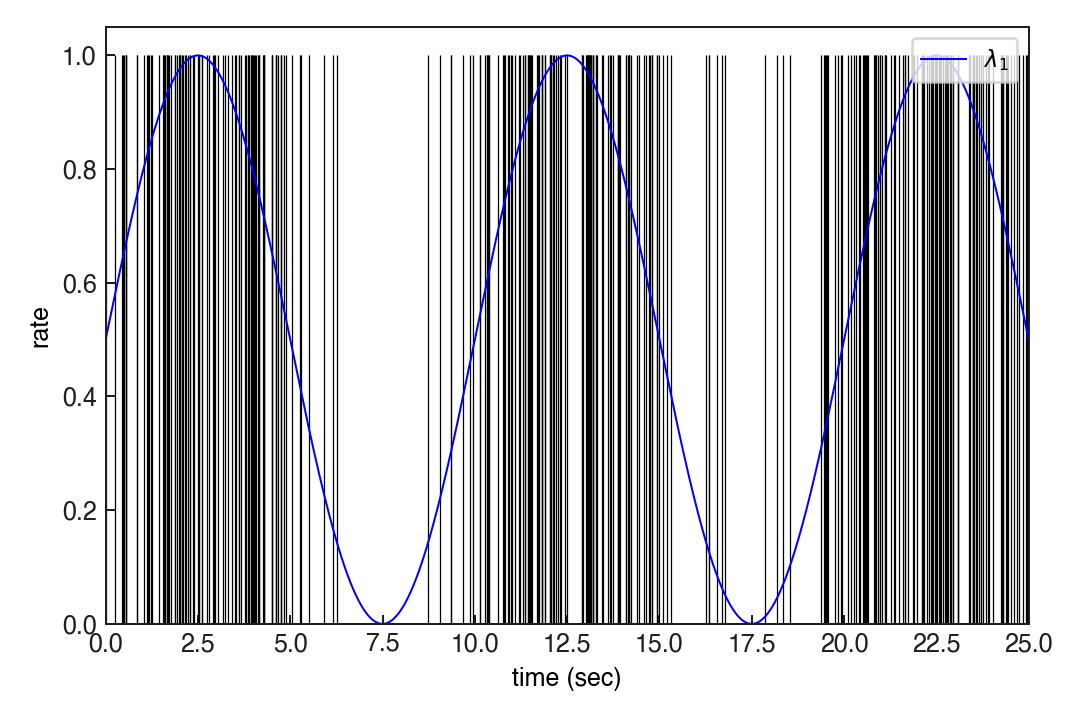

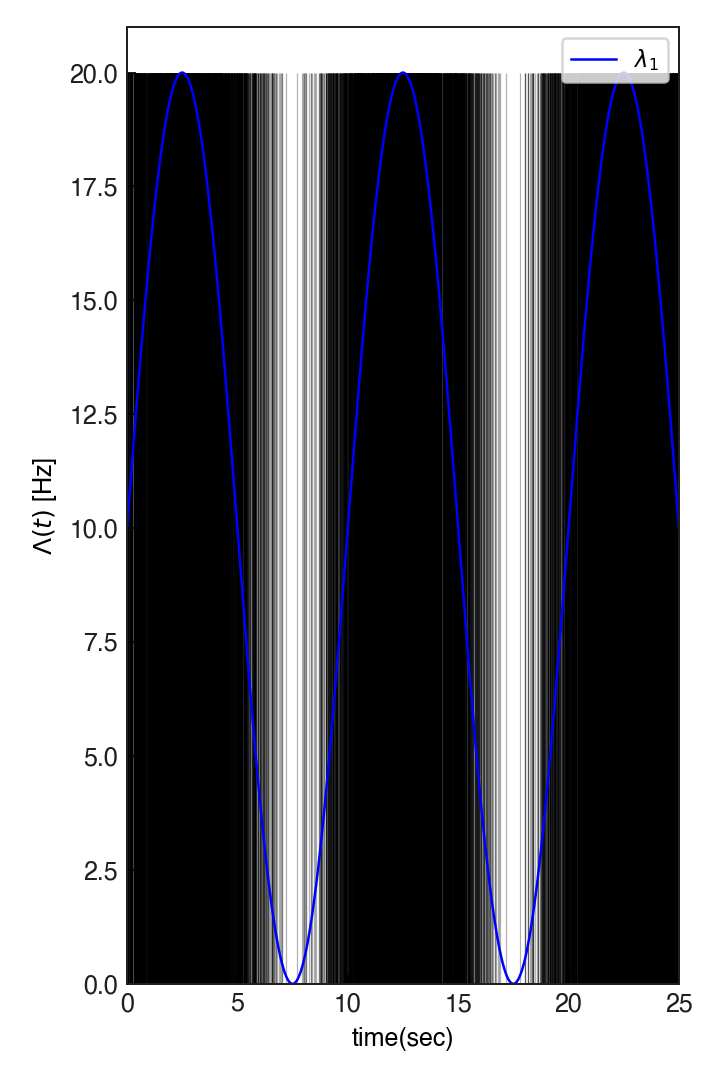

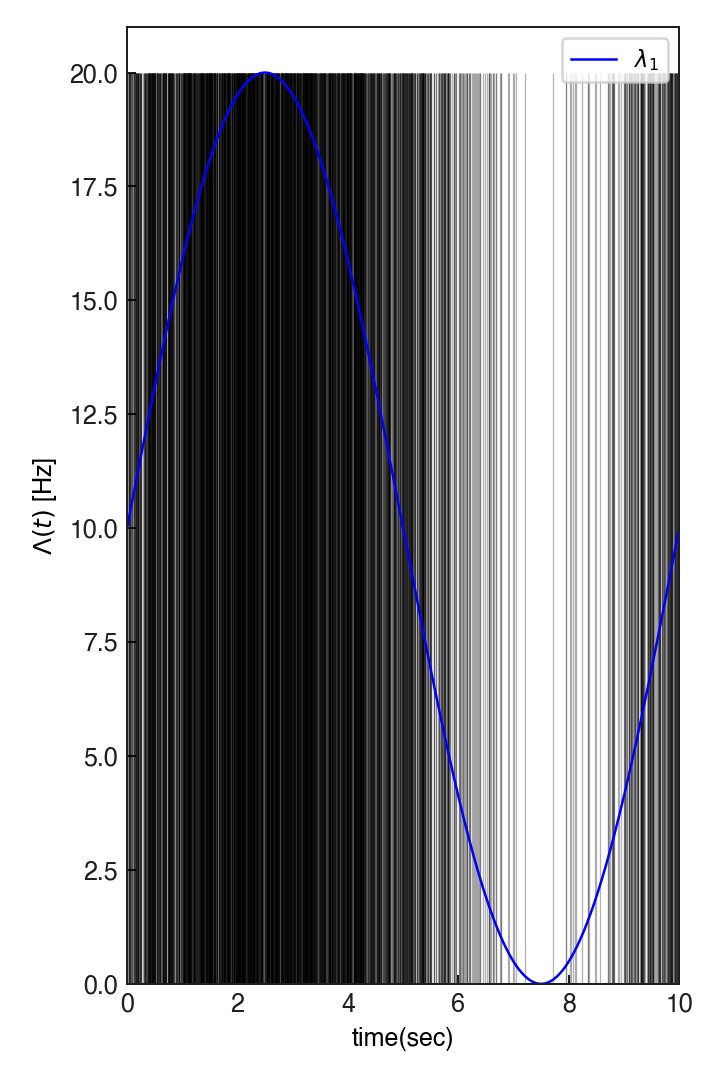

In [ ]:
# SECTION 2: Compare Constant rate process vs. thinned process
def _start_fig(label, figsize=(8.0, 4.5)):
    # Open a tracker slot, then discard the placeholder axes/title cleanly so
    # nothing from the placeholder leaks into the saved PNG.
    fig = __tracker.new_figure(label)
    fig.clf()
    fig.set_size_inches(*figsize)
    __tracker._active_fig = fig
    __tracker._active_ax = None
    return fig

# Figure 1: 2 rows x 2 cols with width_ratios=[3,1] — raster wide, ISI hist narrow.
# Matches MATLAB layout where each row pairs a tall wide raster with a tight
# ISI histogram on the right. ~20 bins, white face with thin black edges to
# mirror MATLAB hist() default appearance.
fig1 = _start_fig("constant-rate vs thinned process", figsize=(9.0, 5.5))
gs = fig1.add_gridspec(2, 2, width_ratios=[3, 1])
ax = fig1.add_subplot(gs[0, 0]); n1.plot(currentHandle=ax)
ax.plot(tSpikes, np.ones_like(tSpikes), '.', color='tab:orange', markersize=3)
ax.set_xlim(0, Tmax/4); ax.set_title("constant-rate raster"); ax.set_xlabel('time [s]')
ax = fig1.add_subplot(gs[0, 1])
ax.hist(np.diff(tSpikes) * 1000.0, bins=20, color='white', edgecolor='black', linewidth=0.5)
ax.set_xlabel('ISI (msec)'); ax.set_ylabel('Spike Counts'); ax.set_title("constant ISI hist")
ax = fig1.add_subplot(gs[1, 0]); n2.plot(currentHandle=ax)
ax.plot(tThin, np.ones_like(tThin), '.', color='tab:orange', markersize=3)
ax.set_xlim(0, Tmax/4); ax.set_title("thinned raster"); ax.set_xlabel('time [s]')
# Bottom-right: thinned-process ISI histogram (matches MATLAB hist(diff(tThin))).
ax = fig1.add_subplot(gs[1, 1])
ax.hist(np.diff(tThin) * 1000.0, bins=20, color='white', edgecolor='black', linewidth=0.5)
ax.set_xlabel('ISI (msec)'); ax.set_ylabel('Spike Counts'); ax.set_title("thinned ISI hist")
fig1.tight_layout()

# Figure 2: thinned spikes + scaled rate p(t) — single panel matching MATLAB's
# squarish portrait aspect. Y-label is 'rate' (lambda) to match MATLAB; no
# title (MATLAB panel is untitled).
fig2 = _start_fig("thinned spikes + scaled rate", figsize=(6.0, 4.0))
ax2 = fig2.add_subplot(1,1,1)
ax2.vlines(tThin, 0, 1, color='k', linewidth=0.5)
# MATLAB plot() default LineWidth is ~0.5; use 0.8 so the rate overlay sits
# behind raster ticks rather than dominating the panel.
ax2.plot(time, lambdaData / lambdaBound, "b", linewidth=0.8, label=r'$\lambda_1$')
ax2.set_xlim(0, Tmax/4); ax2.set_ylim(0, 1.05)
ax2.set_xlabel('time (sec)'); ax2.set_ylabel('rate')
# Match MATLAB's denser x-tick layout (~6 ticks across 25 s).
from matplotlib.ticker import MaxNLocator as _MaxNLocator
ax2.xaxis.set_major_locator(_MaxNLocator(nbins=10))
ax2.legend(loc='upper right')
fig2.tight_layout()

## Simulate multiple realizations of a point process via thinning

The CIF class can generated realizations of a point process given a conditional intensity function (defined as a Covariate or SignalObj)

In [ ]:
# SECTION 3: Simulate multiple realizations of a point process via thinning
spikeColl = CIF.simulateCIFByThinningFromLambda(lam, 20, seed=1)

# Figure 3: 20-realization dense raster overlay + lambda overlay, zoomed to
# [0, Tmax/4]. MATLAB renders all trial spike times stacked on the SAME
# y-range (no per-trial offset) so the raster reads as a density image with
# the blue lambda(t) curve drawn on top. Match that by drawing each trial's
# vlines spanning the full lambda y-range with low alpha.
fig3 = _start_fig("20 thinning realizations + rate", figsize=(4.0, 6.0))
ax3 = fig3.add_subplot(1,1,1)
_lam_max = float(np.max(lambdaData))
for i in range(spikeColl.numSpikeTrains):
    st = spikeColl.getNST(i)
    ax3.vlines(np.asarray(st.spikeTimes), 0, _lam_max,
               color='k', linewidth=0.5, alpha=0.3)
# Blue lambda(t) on top of the dense overlay.
ax3.plot(time, lambdaData, "b", linewidth=1.0, label=r'$\lambda_1$')
ax3.set_xlim(0, Tmax/4)
ax3.set_ylim(0, _lam_max * 1.05)
ax3.set_xlabel('time(sec)')
ax3.set_ylabel(r'$\Lambda(t)$ [Hz]')
ax3.legend(loc='upper right')

# Figure 4: same content with tighter zoom — MATLAB shows the portrait raster
# panel with x-axis cropped to the first few seconds. Same dense-overlay
# styling as fig 3 so the lambda-vs-density relationship reads cleanly.
fig4 = _start_fig("20 realizations + rate (zoomed)", figsize=(4.0, 6.0))
ax4 = fig4.add_subplot(1,1,1)
for i in range(spikeColl.numSpikeTrains):
    st = spikeColl.getNST(i)
    ax4.vlines(np.asarray(st.spikeTimes), 0, _lam_max,
               color='k', linewidth=0.5, alpha=0.3)
ax4.plot(time, lambdaData, "b", linewidth=1.0, label=r'$\lambda_1$')
ax4.set_xlim(0, 10.0)
ax4.set_ylim(0, _lam_max * 1.05)
ax4.set_xlabel('time(sec)')
ax4.set_ylabel(r'$\Lambda(t)$ [Hz]')
ax4.legend(loc='upper right')

__tracker.finalize()